In [89]:
import pandas as pd

In [90]:
# Load dataset
print("Andrianna Wardill")
df = pd.read_csv('Forbes-list-2020.csv')
df.head()

Andrianna Wardill


,Name,NetWorth in billions,Country,Source,Rank,Age,Industry
0,Jeff Bezos,177.0,United States,Amazon,1,57,Technology
1,Elon Musk,151.0,United States,"Tesla, SpaceX",2,49,Automotive
2,Bernard Arnault & family,150.0,France,LVMH,3,72,Fashion & Retail
3,Bill Gates,124.0,United States,Microsoft,4,65,Technology
4,Mark Zuckerberg,97.0,United States,Facebook,5,36,Technology


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2755 entries, 0 to 2754
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Name                  2755 non-null   object 
 1   NetWorth in billions  2755 non-null   float64
 2   Country               2755 non-null   object 
 3   Source                2755 non-null   object 
 4   Rank                  2755 non-null   int64  
 5   Age                   2755 non-null   int64  
 6   Industry              2755 non-null   object 
dtypes: float64(1), int64(2), object(4)
memory usage: 150.8+ KB


### Q1: Univariate Analysis
Compute summary statistics (mean, median, min, max, std) for `NetWorth` and `Age`. Identify the youngest and oldest billionaires.

In [73]:
df.describe()

,NetWorth in billions,Rank,Age
count,2755.000000,2755.000000,2755.000000
mean,4.749220,1345.663521,63.014519
std,9.615358,772.669811,13.259017
min,1.000000,1.000000,18.000000
25%,1.500000,680.000000,54.000000
50%,2.300000,1362.000000,62.000000
75%,4.200000,2035.000000,72.000000
max,177.000000,2674.000000,97.000000


## Observation
- Networth - Mean: 4.7, Median: 2.3, Min: 1, Max: 177, Std: 9.6
- Age - Mean: 63, Median: 62, Min: 18, Max: 97, Std: 13.3

### Q2: Bivariate Analysis (Categorical vs Numerical)
Compare the average `NetWorth` across different `Industries`. Which industry has the highest average net worth?

In [74]:

# Group by industry
group = df.groupby('Industry')['NetWorth in billions'].mean()
high_avg_group = group.idxmax()
high_avg_value = group[high_avg_group]
print("Group: {g} \nAverage: {a}".format(g=high_avg_group, a=high_avg_value))

Group: Automotive 
Average: 6.875


## Obersavtion
- The Automotive group has the highest average net worth of approximately 6.9 billion dollars across the different industries

### Q3: Bivariate Analysis (Numerical vs Numerical)
Explore the relationship between `Age` and `NetWorth` using a scatterplot. Do younger billionaires tend to have higher net worth than older ones?

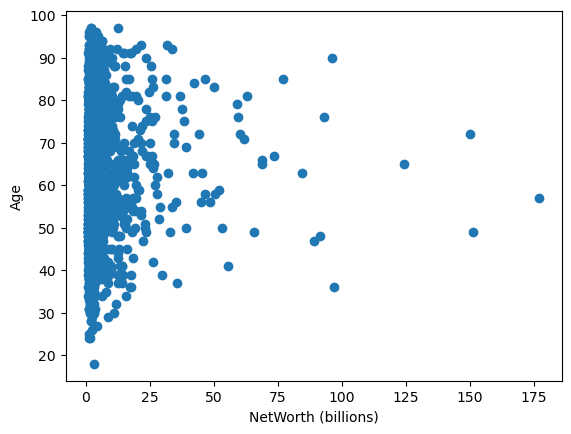

In [75]:

import matplotlib.pyplot as plt

# Use Scatter plot with pandas
plt.scatter(df['NetWorth in billions'], df['Age'])
plt.xlabel("NetWorth (billions)")
plt.ylabel("Age")
plt.show()

## Oberservation
- Based on the scatter plot, there are many values clustered together thereby making it difficult to determine a correlation of age and networth.
- However, due to outliers I can deduce that it does appear that when age increases so does the networth.

### Q4: Country Profile
Which Country has the highest number of billionaires in the Technology industry using crosstab?

In [98]:
# filtered for technology industry
tech = df[df['Industry']=="Technology"]
# cross tab for count of billionars in the tech industry across each country
country = pd.crosstab(index = tech['Country'],columns='count')
country_sort = country.sort_values(by='count', ascending=False)
country_index = country_sort.iloc[0,]
country_index

col_0
count    140
Name: United States, dtype: int64

## Oberservation
- The United States has the highest number of billionares in the technology industry

### Q5: Standardization using Z-score
Identify outliers based on Networth (z-score > 2 or < -2).

In [77]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [99]:
df[['Networth_Z']] = scaler.fit_transform(df[['NetWorth in billions']])

In [100]:
outliers = df[df['Networth_Z'].abs()>2]
outliers.count()

Name                    69
NetWorth in billions    69
Country                 69
Source                  69
Rank                    69
Age                     69
Industry                69
Networth_Z              69
dtype: int64

## Obeservation
- There are 69 outliers that have a z-score > 2 or < -2

### Q6: Normalization
Normalize the `NetWorth` column to a 0-1 scale using min-max normalization.

In [83]:
from sklearn.preprocessing import MinMaxScaler
norm = MinMaxScaler()

In [84]:
df[['NetWorth_Norm']] = norm.fit_transform(df[['NetWorth in billions']])
df.head()

,Name,NetWorth in billions,Country,Source,Rank,Age,Industry,Networth_Z,NetWorth_Norm
0,Jeff Bezos,177.0,United States,Amazon,1,57,Technology,17.917382,1.000000
1,Elon Musk,151.0,United States,"Tesla, SpaceX",2,49,Automotive,15.212884,0.852273
2,Bernard Arnault & family,150.0,France,LVMH,3,72,Fashion & Retail,15.108865,0.846591
3,Bill Gates,124.0,United States,Microsoft,4,65,Technology,12.404367,0.698864
4,Mark Zuckerberg,97.0,United States,Facebook,5,36,Technology,9.595849,0.545455


## Obeservation
- The dataframe head above displays the networth in billions column normalized to a scale from 0 to 1

### Q7: Correlation and Covariance
Compute correlation and covariance between `Age` and `NetWorth`. What does the result suggest?

In [87]:
col = df[['Age','NetWorth in billions']]
#col
col.cov()

,Age,NetWorth in billions
Age,175.801532,4.490861
NetWorth in billions,4.490861,92.455115


### Observation
- Age-Age and NetWorth-NetWorth each have a large numbers, this suggests that there is a large spread of values rather than being tihgtly clustered
- NetWorth in covariance to Age is 4.5, this suggest as Age or NetWorth increase the other will increase with it
    - However, 4.5 in comparison to Age-Age and NetWorth-NetWorth indicates that there is a weak relationship

In [88]:
col.corr()

,Age,NetWorth in billions
Age,1.000000,0.035225
NetWorth in billions,0.035225,1.000000


### Observation
- The correlation matrix of Age-NetWorth is 0.04, this supports the same idea of the covariance that the relationship between Age-NetWorth is positive, however the strength of the relationship is weak